LAB 7: Recurrent Neural Networks (RNNs)

OBJECTIVE: Predict sequences using RNN

DATASET: Synthetic Sine wave Dataset

THEORY:

- Recurrent Neural Networks (RNNs) are designed to process sequential data.

- They have feedback connections, allowing information to persist across time steps.

- RNNs are suitable for time-series prediction, language modeling, and sequence classification.

- Using sequences, an RNN learns the temporal dependencies to predict the next value.

- Tools like TensorFlow/Keras simplify building and training RNN models.

ALGORITHM (RNN FOR SEQUENCE PREDICTION)

- Generate a synthetic sine wave as a time series

- Prepare input-output pairs (e.g., previous 10 points → predict next point)

- Reshape data to fit RNN input requirements (samples, timesteps, features)

- Build an RNN model (SimpleRNN or LSTM) using Keras

- Compile model with optimizer and loss function

- Train the network on the training data

- Predict next values and compare with actual sine wave

- Visualize predictions vs actual sequence

SOURCE CODE:

CELL 1: IMPORT LIBRARIES

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

CELL 2: GENERATE SYNTHETIC SINE WAVE

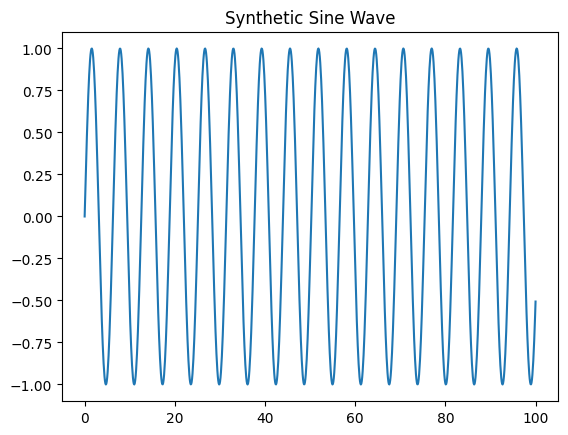

In [21]:
# Generate sine wave
time_steps = np.linspace(0, 100, 1000)
data = np.sin(time_steps)

# Plot sine wave
plt.plot(time_steps, data)
plt.title("Synthetic Sine Wave")
plt.show()

CELL 3: PREPARE DATA FOR RNN

In [22]:
# Function to create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(data, seq_length)

# Reshape for RNN: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

CELL 4: BUILD RNN MODEL

In [23]:
model = Sequential()
model.add(Input(shape=(seq_length, 1)))   # define input shape using Input layer
model.add(SimpleRNN(50, activation='tanh')) # RNN layer
model.add(Dense(1))                        # output layer

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

CELL 5: TRAIN MODEL

In [24]:
history = model.fit(X, y, epochs=30, batch_size=32, validation_split=0.2)

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0204 - val_loss: 0.0016
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.7214e-04 - val_loss: 2.7439e-04
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3614e-04 - val_loss: 1.5005e-04
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2033e-04 - val_loss: 5.0343e-05
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.0940e-05 - val_loss: 5.9055e-05
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.1169e-05 - val_loss: 2.2992e-05
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3305e-05 - val_loss: 9.0458e-06
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.8210e-06 - val_loss: 3.0431e-06
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.0636e-06 - val_loss: 2.5112e-06
Epoch 10/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0943e-06 - val_loss: 2.7067e-06
Epoch 11/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.1025e-06 - val_loss: 4.27

CELL 6: PREDICT AND VISUALIZE

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


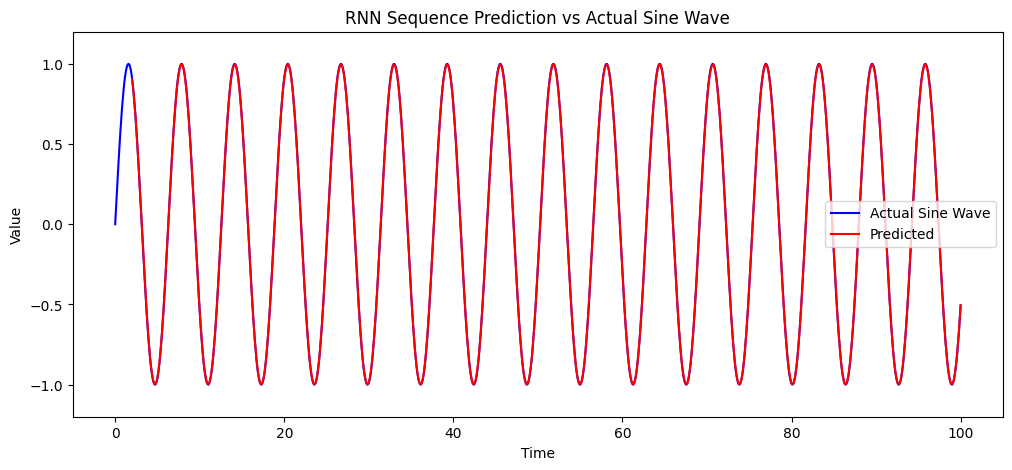

In [25]:
# Predict sequence
y_pred = model.predict(X)

plt.figure(figsize=(12,5))

# Plot full sine wave
plt.plot(time_steps, data, label='Actual Sine Wave', color='blue')

# Align predictions to sequence start
plt.plot(time_steps[
    seq_length:], y_pred.flatten(), label='Predicted', color='red')

plt.title("RNN Sequence Prediction vs Actual Sine Wave")
plt.xlabel("Time")
plt.ylabel("Value")
plt.ylim(-1.2, 1.2)  # ensure full sine wave is visible
plt.legend()
plt.show()

RESULTS:

- The RNN successfully learned the pattern of the sine wave.

- Predictions closely follow the actual sine wave after training.

- Training loss decreased steadily, showing the network converged to the sequence pattern.

- The model can predict the next value in the sequence based on previous points.

CONCLUSION:

- RNNs can capture temporal dependencies in sequential data.

- Using feedback connections, the network learns to predict future points in time series.

- This lab demonstrates sequence prediction with a simple synthetic dataset.

- RNNs provide a foundation for more advanced sequence tasks like stock prediction, language modeling, and signal processing.